# BKK_RAIN_CV1 — seasonal cross-validation for BKK_Rain_V1

[`Thailand_Rain_Seasonal_CV.ipynb`](Thailand_Rain_Seasonal_CV.ipynb) ran this idea on
`OM_THAILAND_DATA_PRECOMPUTE` and closed with an honest caveat:

> Only 12 months exist, so each held-out block is also an unseen season. Degradation
> mixes "harder season" with "season never trained on"; multi-year data is required
> to separate the two.

`OM_BKK_DATA_PRECOMPUTE` spans five years, so that separation is possible here.

| part | held out | the model has... | question it answers |
|---|---|---|---|
| **A** | one calendar **year** | ...seen this season, in other years | how hard is this month, intrinsically? |
| **B** | one calendar **quarter**, in every year | ...never seen this season | what does an unseen season cost? |
| **C** | A vs B on the same rows | — | how much of the seasonal drop is unfamiliarity? |

Part A also replaces the single chronological split of `BKK_Rain_V1`: every row gets an
out-of-fold prediction from a model that never saw its year.

`BKK_Rain_V1`'s reported test base rate is 0.162 at 1 h against a full-table rate of
0.221, because its test window (2025-10-19 onward) is dry-season heavy while its
validation window is wet-season heavy (0.269). Monthly `rain_any_next_1h` in this table
ranges from 0.036 to 0.472 — a 13x swing — so a single contiguous split cannot produce a
representative estimate of anything.

Read-only against the database. Trains models in memory and writes metrics; it does not
overwrite any `BKK_Rain_V1` artefact.

In [1]:
import gc
import json
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Configuration

Model plan, hyperparameters and the row filter are copied verbatim from `BKK_Rain_V1`
so that any difference in the numbers comes from the split scheme and nothing else.
The one deliberate change is `USE_LIGHTGBM_EARLY_STOPPING = False`: V1 used a
chronological validation split to pick the tree count, and there is no such split here.
Every fold therefore gets exactly 500 trees, matching the Thailand CV.

In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

PRECOMPUTE_TABLE_NAME = '"OM_BKK_DATA_PRECOMPUTE"'
PROJECT_ROOT = Path.cwd()
V1_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "om_bkk_rain_any_v1"
OUTPUT_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "om_bkk_rain_any_seasonal_cv"

HORIZONS = [1, 2, 3, 6]
RAIN_THRESHOLD_MM = 0.1
MODEL_PLAN = {1: "lightgbm", 2: "lightgbm", 3: "hist_gradient_boosting", 6: "hist_gradient_boosting"}
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)
RANDOM_STATE = 42

# Hours of training data dropped either side of every test block, so a lag or rolling
# window cannot straddle the boundary. 24 h covers the deepest feature
# (precipitation_sum_past_24h) and matches the Thailand CV.
PURGE_HOURS = 24

# Part A holds out a whole year; Part B holds out a quarter of the calendar in every year.
QUARTERS = {1: [1, 2, 3], 2: [4, 5, 6], 3: [7, 8, 9], 4: [10, 11, 12]}

# The volume control (section 6) reruns Part A with the training set cut to Part B's size.
# Only 1 h, because it exists to rule out one confound rather than to be a third estimate.
VOLUME_CONTROL_HORIZON = 1

# A year needs enough rows to be a fold; the first and last years of the table are partial.
MIN_FOLD_ROWS = 50_000


def load_v1_thresholds(path, fallback):
    """V1's operating points. Every month is scored at these, which is the comparison."""
    try:
        meta = json.loads(Path(path).read_text(encoding="utf-8"))
    except FileNotFoundError:
        print(f"{path} not found; using fallback thresholds {fallback}")
        return fallback
    for key in ("selected_probability_thresholds", "probability_thresholds", "thresholds"):
        if key in meta:
            return {int(k): float(v) for k, v in meta[key].items()}
    print(f"No threshold key in {path}; using fallback {fallback}")
    return fallback


V1_THRESHOLDS = load_v1_thresholds(V1_DIR / "bkk_rain_v1_metadata.json",
                                   {1: 0.60, 2: 0.55, 3: 0.35, 6: 0.35})
print(f"Source table   : {PRECOMPUTE_TABLE_NAME}")
print(f"V1 thresholds  : {V1_THRESHOLDS}")
print(f"Output         : {OUTPUT_DIR}")

Source table   : "OM_BKK_DATA_PRECOMPUTE"
V1 thresholds  : {3: 0.3500000000000001, 6: 0.3500000000000001, 1: 0.6000000000000002, 2: 0.5500000000000002}
Output         : C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\om_bkk_rain_any_seasonal_cv


## 2. Features

Identical to `BKK_Rain_V1`: 36 baseline columns plus 30 neighbourhood columns.

In [3]:
BASELINE_FEATURE_COLUMNS = [
    "temperature_2m", "relative_humidity_2m", "pressure_msl", "surface_pressure",
    "dew_point_2m", "precipitation", "cloud_cover", "wind_speed_10m",
    "wind_direction_10m", "temperature_dew_point_spread", "pressure_msl_change_3h",
    "pressure_msl_change_6h", "precipitation_lag_1h", "precipitation_lag_2h",
    "precipitation_lag_3h", "precipitation_lag_6h", "precipitation_sum_past_3h",
    "precipitation_sum_past_6h", "precipitation_sum_past_12h", "precipitation_sum_past_24h",
    "cloud_cover_lag_1h", "cloud_cover_lag_3h", "cloud_cover_lag_6h",
    "humidity_lag_1h", "humidity_lag_3h", "humidity_lag_6h",
    "wind_speed_lag_1h", "wind_speed_lag_3h", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "grid_row", "grid_column", "latitude", "longitude",
]

NEIGHBOR_FEATURE_COLUMNS = [
    "neighbor_count", "neighbor_precipitation_mean", "neighbor_precipitation_max",
    "neighbor_precipitation_sum", "neighbor_rain_count", "neighbor_rain_rate",
    "neighbor_cloud_cover_mean", "neighbor_cloud_cover_max", "neighbor_relative_humidity_mean",
    "neighbor_relative_humidity_max", "neighbor_pressure_msl_mean", "neighbor_pressure_msl_min",
    "neighbor_pressure_msl_max", "neighbor_temperature_2m_mean", "neighbor_dew_point_2m_mean",
    "neighbor_temperature_dew_point_spread_mean", "neighbor_wind_speed_10m_mean",
    "neighbor_wind_speed_10m_max", "row_minus_precipitation_mean", "row_plus_precipitation_mean",
    "column_minus_precipitation_mean", "column_plus_precipitation_mean", "row_minus_cloud_cover_mean",
    "row_plus_cloud_cover_mean", "column_minus_cloud_cover_mean", "column_plus_cloud_cover_mean",
    "neighbor_precipitation_mean_minus_center", "neighbor_cloud_cover_mean_minus_center",
    "neighbor_relative_humidity_mean_minus_center", "center_pressure_msl_minus_neighbor_mean",
]

FEATURE_COLUMNS = BASELINE_FEATURE_COLUMNS + NEIGHBOR_FEATURE_COLUMNS
TARGET_COLUMNS = [f"rain_any_next_{h}h" for h in HORIZONS]
print(f"Features: {len(FEATURE_COLUMNS)}  targets: {TARGET_COLUMNS}")

Features: 66  targets: ['rain_any_next_1h', 'rain_any_next_2h', 'rain_any_next_3h', 'rain_any_next_6h']


## 3. Load the panel

Streamed into preallocated `float32` / `int8` arrays, as in V1 — `month_sin`/`month_cos`
stay in the feature set, so the model still knows what time of year it is even when the
season is held out.

In [4]:
ROW_FILTER_SQL = f'''
    WHERE pressure_msl_change_6h IS NOT NULL
      AND precipitation_lag_6h IS NOT NULL
      AND precipitation_sum_past_24h IS NOT NULL
      AND cloud_cover_lag_6h IS NOT NULL
      AND humidity_lag_6h IS NOT NULL
      AND wind_speed_lag_3h IS NOT NULL
      AND rain_any_next_{max(HORIZONS)}h IS NOT NULL
      AND neighbor_count > 0
'''


def connect():
    return psycopg2.connect(**DB_CONFIG)


def read_training_data(batch_size=250_000):
    feature_sql = ",\n        ".join(
        f"COALESCE({c}::real, 'NaN'::real) AS {c}" for c in FEATURE_COLUMNS
    )
    target_sql = ",\n        ".join(f"{t}::smallint" for t in TARGET_COLUMNS)
    query = f'''
    SELECT grid_number, local_forecast_time,
        {feature_sql},
        {target_sql}
    FROM {PRECOMPUTE_TABLE_NAME}
    {ROW_FILTER_SQL}
    ORDER BY local_forecast_time, grid_number
    '''
    with connect() as conn:
        with conn.cursor() as cur:
            cur.execute(f"SELECT count(*) FROM {PRECOMPUTE_TABLE_NAME} {ROW_FILTER_SQL}")
            n_rows = cur.fetchone()[0]
        print(f"Allocating {n_rows:,} x {len(FEATURE_COLUMNS)} float32 "
              f"({n_rows * len(FEATURE_COLUMNS) * 4 / 1e9:.2f} GB)")

        x = np.empty((n_rows, len(FEATURE_COLUMNS)), dtype="float32")
        y = np.empty((n_rows, len(TARGET_COLUMNS)), dtype="int8")
        t = np.empty(n_rows, dtype="datetime64[s]")
        unit = np.empty(n_rows, dtype="int32")
        n_feat = len(FEATURE_COLUMNS)
        filled = 0
        with conn.cursor(name="bkk_cv_stream") as cur:
            cur.itersize = batch_size
            cur.execute(query)
            while filled < n_rows:
                batch = cur.fetchmany(batch_size)
                if not batch:
                    break
                block = np.asarray(batch, dtype="object")
                take = len(batch)
                unit[filled:filled + take] = block[:, 0].astype("int32")
                t[filled:filled + take] = block[:, 1].astype("datetime64[s]")
                x[filled:filled + take] = block[:, 2:2 + n_feat].astype("float32")
                y[filled:filled + take] = block[:, 2 + n_feat:].astype("int8")
                filled += take
                print(f"  {filled:,} / {n_rows:,}", end="\r", flush=True)
        print()
    return x[:filled], y[:filled], t[:filled], unit[:filled]


started = time.time()
x_all, y_all, forecast_time, unit_id = read_training_data()
print(f"Loaded {x_all.shape[0]:,} rows in {(time.time()-started)/60:.1f} min "
      f"({x_all.nbytes/1e9:.2f} GB)")
print(f"{forecast_time.min()} .. {forecast_time.max()}   units: {np.unique(unit_id).size}")

Allocating 2,453,568 x 66 float32 (0.65 GB)


Loaded 2,453,568 rows in 2.2 min (0.65 GB)


2021-07-20T06:00:00 .. 2026-07-19T21:00:00   units: 56


In [5]:
stamps = pd.to_datetime(forecast_time)
year_key = stamps.year.to_numpy()
month_of_year = stamps.month.to_numpy()
month_key = pd.PeriodIndex(stamps, freq="M").astype(str).to_numpy()
quarter_key = np.select([np.isin(month_of_year, m) for m in QUARTERS.values()],
                        list(QUARTERS.keys()))
unique_months = sorted(pd.unique(month_key))

print(f"{len(unique_months)} months: {unique_months[0]} .. {unique_months[-1]}")
display(pd.DataFrame({
    "year": year_key, "rain_1h": y_all[:, 0], "rain_6h": y_all[:, 3],
}).groupby("year").agg(rows=("rain_1h", "size"), rain_rate_1h=("rain_1h", "mean"),
                       rain_rate_6h=("rain_6h", "mean")))

61 months: 2021-07 .. 2026-07


,rows,rain_rate_1h,rain_rate_6h
year,,,
2021,221424,0.3074,0.5117
2022,490560,0.2447,0.4658
2023,490560,0.1957,0.4085
2024,491904,0.2001,0.4106
2025,490560,0.2287,0.4637
2026,268560,0.1730,0.3908


## 4. Fold construction

`purged_train_mask` drops any training row within `PURGE_HOURS` of *any* held-out
timestamp. It works off unique timestamps rather than row positions, which matters
because each hour appears once per grid cell — dilating by row count would purge
56x too little.

The same function serves both parts, so Part B's four disjoint blocks per year are
purged exactly as carefully as Part A's single contiguous one.

In [6]:
PURGE = np.timedelta64(PURGE_HOURS, "h")


def purged_train_mask(test_mask, times=forecast_time, purge=PURGE):
    """Training rows: not held out, and not within `purge` of any held-out timestamp."""
    test_times = np.unique(times[test_mask])
    position = np.searchsorted(test_times, times)
    left = test_times[np.clip(position - 1, 0, len(test_times) - 1)]
    right = test_times[np.clip(position, 0, len(test_times) - 1)]
    distance = np.minimum(np.abs(times - left), np.abs(times - right))
    return ~test_mask & (distance > purge)


candidate_years = [int(y) for y in np.unique(year_key)]
YEAR_FOLDS = [y for y in candidate_years if (year_key == y).sum() >= MIN_FOLD_ROWS]
dropped = sorted(set(candidate_years) - set(YEAR_FOLDS))
if dropped:
    print(f"Years too small to be a fold (kept in training only): {dropped}")

fold_rows = []
for year in YEAR_FOLDS:
    test_mask = year_key == year
    train_mask = purged_train_mask(test_mask)
    fold_rows.append({"part": "A_year", "fold": str(year), "test_rows": int(test_mask.sum()),
                      "train_rows": int(train_mask.sum()),
                      "purged_rows": int(len(forecast_time) - test_mask.sum() - train_mask.sum()),
                      "test_rain_rate_1h": float(y_all[test_mask, 0].mean())})
for quarter, month_list in QUARTERS.items():
    test_mask = quarter_key == quarter
    train_mask = purged_train_mask(test_mask)
    fold_rows.append({"part": "B_quarter", "fold": f"Q{quarter} {month_list}",
                      "test_rows": int(test_mask.sum()), "train_rows": int(train_mask.sum()),
                      "purged_rows": int(len(forecast_time) - test_mask.sum() - train_mask.sum()),
                      "test_rain_rate_1h": float(y_all[test_mask, 0].mean())})

fold_table = pd.DataFrame(fold_rows)
display(fold_table)

mean_train_a = fold_table.loc[fold_table["part"] == "A_year", "train_rows"].mean()
mean_train_b = fold_table.loc[fold_table["part"] == "B_quarter", "train_rows"].mean()
print(f"Part A trains on a mean {mean_train_a:,.0f} rows, Part B on {mean_train_b:,.0f} "
      f"({mean_train_a / mean_train_b - 1:+.1%}) — section 6 controls for the difference.")

,part,fold,test_rows,train_rows,purged_rows,test_rain_rate_1h
0,A_year,2021,221424,2230800,1344,0.3074
1,A_year,2022,490560,1960320,2688,0.2447
2,A_year,2023,490560,1960320,2688,0.1957
3,A_year,2024,491904,1958976,2688,0.2001
4,A_year,2025,490560,1960320,2688,0.2287
5,A_year,2026,268560,2183664,1344,0.1730
6,B_quarter,"Q1 [1, 2, 3]",606144,1833984,13440,0.0829
7,B_quarter,"Q2 [4, 5, 6]",611520,1828608,13440,0.2290
8,B_quarter,"Q3 [7, 8, 9]",617664,1822464,13440,0.4006
9,B_quarter,"Q4 [10, 11, 12]",618240,1821888,13440,0.1674


Part A trains on a mean 2,042,400 rows, Part B on 1,826,736 (+11.8%) — section 6 controls for the difference.


## 5. Run both CV parts

Hyperparameters exactly as V1 / the Thailand CV, so the only moving part is the split.

In [7]:
def fit_predict(x_train, y_train, x_test, model_name):
    if model_name == "lightgbm":
        scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
        model = LGBMClassifier(
            objective="binary", n_estimators=500, learning_rate=0.04, num_leaves=63,
            min_child_samples=80, subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
            n_jobs=-1, verbose=-1,
        )
    else:
        model = HistGradientBoostingClassifier(
            learning_rate=0.06, max_iter=250, max_leaf_nodes=31,
            l2_regularization=0.05, random_state=RANDOM_STATE, early_stopping=False,
        )
    model.fit(x_train, y_train)
    probabilities = model.predict_proba(x_test)[:, 1].astype("float32")
    del model
    gc.collect()
    return probabilities


def run_cv(fold_masks, label):
    """fold_masks: list of (fold_name, test_mask). Returns OOF probabilities + a log."""
    oof = np.full((x_all.shape[0], len(HORIZONS)), np.nan, dtype="float32")
    log = []
    started_all = time.time()
    for fold_name, test_mask in fold_masks:
        train_mask = purged_train_mask(test_mask)
        x_train, x_test = x_all[train_mask], x_all[test_mask]
        print(f"\n=== {label} fold {fold_name}: test {test_mask.sum():,}, "
              f"train {train_mask.sum():,} ===", flush=True)
        for horizon_index, horizon in enumerate(HORIZONS):
            model_name = MODEL_PLAN[horizon]
            started = time.time()
            oof[test_mask, horizon_index] = fit_predict(
                x_train, y_all[train_mask, horizon_index], x_test, model_name)
            elapsed = time.time() - started
            log.append({"part": label, "fold": fold_name, "horizon_h": horizon,
                        "model": model_name, "train_rows": int(train_mask.sum()),
                        "test_rows": int(test_mask.sum()), "fit_seconds": elapsed})
            print(f"  {horizon}h {model_name}: {elapsed/60:.1f} min", flush=True)
        del x_train, x_test
        gc.collect()
    print(f"\n{label} finished in {(time.time()-started_all)/60:.1f} min; "
          f"coverage {np.isfinite(oof).all(axis=1).mean():.4f}")
    return oof, log


oof_a, log_a = run_cv([(str(y), year_key == y) for y in YEAR_FOLDS], "A_year")
oof_b, log_b = run_cv([(f"Q{q}", quarter_key == q) for q in QUARTERS], "B_quarter")

fold_log = pd.DataFrame(log_a + log_b)
display(fold_log.groupby(["part", "horizon_h"])["fit_seconds"].agg(["count", "mean", "sum"]))


=== A_year fold 2021: test 221,424, train 2,230,800 ===


  1h lightgbm: 1.8 min


  2h lightgbm: 0.8 min


  3h hist_gradient_boosting: 1.2 min


  6h hist_gradient_boosting: 0.7 min


...

  2h lightgbm: 0.6 min


  3h hist_gradient_boosting: 1.7 min


  6h hist_gradient_boosting: 2.3 min



B_quarter finished in 12.4 min; coverage 1.0000


count    mean      sum
part      horizon_h                        
A_year    1              6 67.0402 402.2413
          2              6 42.2100 253.2599
          3              6 47.9843 287.9061
          6              6 55.6615 333.9689
B_quarter 1              4 36.3294 145.3177
          2              4 34.4382 137.7528
          3              4 52.3486 209.3943
          6              4 62.1364 248.5456

## 6. Volume control

Part A trains on more rows than Part B, so a raw A-vs-B gap conflates "saw the season"
with "saw more data". This rerun gives Part A the *same* number of training rows as the
matching Part B fold, sampled at random from Part A's training pool. If the A-vs-B gap
survives here, it is about season and not volume.

In [8]:
target_train_rows = int(np.mean([m["train_rows"] for m in fold_rows if m["part"] == "B_quarter"]))
horizon_index_vc = HORIZONS.index(VOLUME_CONTROL_HORIZON)
rng = np.random.default_rng(RANDOM_STATE)

oof_a_matched = np.full(x_all.shape[0], np.nan, dtype="float32")
control_log = []
for year in YEAR_FOLDS:
    test_mask = year_key == year
    train_mask = purged_train_mask(test_mask)
    train_index = np.flatnonzero(train_mask)
    if len(train_index) > target_train_rows:
        train_index = np.sort(rng.choice(train_index, target_train_rows, replace=False))
    started = time.time()
    oof_a_matched[test_mask] = fit_predict(
        x_all[train_index], y_all[train_index, horizon_index_vc],
        x_all[test_mask], MODEL_PLAN[VOLUME_CONTROL_HORIZON])
    control_log.append({"fold": str(year), "train_rows": len(train_index),
                        "fit_seconds": time.time() - started})
    print(f"  control {year}: {len(train_index):,} rows, "
          f"{(time.time()-started)/60:.1f} min", flush=True)
display(pd.DataFrame(control_log))

  control 2021: 1,826,736 rows, 0.9 min


  control 2022: 1,826,736 rows, 0.6 min


  control 2023: 1,826,736 rows, 0.6 min


  control 2024: 1,826,736 rows, 0.8 min


  control 2025: 1,826,736 rows, 1.1 min


  control 2026: 1,826,736 rows, 1.9 min


,fold,train_rows,fit_seconds
0,2021,1826736,56.3083
1,2022,1826736,35.1358
2,2023,1826736,38.4499
3,2024,1826736,48.2164
4,2025,1826736,68.6448
5,2026,1826736,113.0511


## 7. Per-month metrics

`roc_auc` and `pr_auc` are computed per calendar month from the Part A out-of-fold
predictions. `f1` uses V1's fixed threshold; `best_f1` re-tunes the threshold within
that month alone. The gap between them is what a single global operating point costs.

In [9]:
def month_metrics(month, horizon_index, horizon, oof, part):
    mask = (month_key == month) & np.isfinite(oof[:, horizon_index])
    if not mask.any():
        return None
    y_true = y_all[mask, horizon_index]
    probabilities = oof[mask, horizon_index]
    row = {"part": part, "month": month, "horizon_h": horizon, "model": MODEL_PLAN[horizon],
           "rows": int(mask.sum()), "rain_rate": float(y_true.mean())}

    if y_true.min() == y_true.max():           # degenerate month, AUC undefined
        row.update({"roc_auc": np.nan, "pr_auc": np.nan, "brier_score": np.nan})
    else:
        row.update({"roc_auc": float(roc_auc_score(y_true, probabilities)),
                    "pr_auc": float(average_precision_score(y_true, probabilities)),
                    "brier_score": float(brier_score_loss(y_true, probabilities))})
    # Brier only means something against the month's own climatology.
    base = float(y_true.mean())
    climatology = base * (1 - base)
    row["brier_climatology"] = climatology
    row["brier_skill"] = (1 - row["brier_score"] / climatology
                          if climatology and np.isfinite(row.get("brier_score", np.nan))
                          else np.nan)

    threshold = V1_THRESHOLDS[horizon]
    y_pred = (probabilities >= threshold).astype("int8")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    row.update({"v1_threshold": threshold,
                "precision": float(precision_score(y_true, y_pred, zero_division=0)),
                "recall": float(recall_score(y_true, y_pred, zero_division=0)),
                "f1": float(f1_score(y_true, y_pred, zero_division=0)),
                "predicted_rain_rate": float(y_pred.mean()),
                "false_positives": int(fp), "false_negatives": int(fn)})

    best_f1, best_threshold = -1.0, np.nan
    for candidate in PROBABILITY_THRESHOLDS_TO_TEST:
        score = f1_score(y_true, (probabilities >= candidate).astype("int8"), zero_division=0)
        if score > best_f1:
            best_f1, best_threshold = float(score), float(candidate)
    row.update({"best_f1": best_f1, "best_threshold": best_threshold,
                "f1_lost_to_fixed_threshold": best_f1 - row["f1"]})
    return row


monthly = pd.DataFrame([
    r for i, horizon in enumerate(HORIZONS) for month in unique_months
    for r in [month_metrics(month, i, horizon, oof_a, "A_year")] if r
]).sort_values(["horizon_h", "month"])

for horizon in HORIZONS:
    print(f"\n===== {horizon}h ({MODEL_PLAN[horizon]}) — Part A, out-of-fold by month =====")
    print(monthly[monthly["horizon_h"] == horizon][
        ["month", "rows", "rain_rate", "roc_auc", "pr_auc", "brier_score", "brier_skill",
         "precision", "recall", "f1", "best_f1", "best_threshold"]].to_string(index=False))


===== 1h (lightgbm) — Part A, out-of-fold by month =====
  month  rows  rain_rate  roc_auc  pr_auc  brier_score  brier_skill  precision  recall     f1  best_f1  best_threshold
2021-07 15792     0.3853   0.9260  0.8893       0.1326       0.4401     0.7405  0.8805 0.8044   0.8135          0.7000
2021-08 41664     0.3997   0.9375  0.9085       0.1114       0.5355     0.7845  0.8746 0.8271   0.8286          0.6500
2021-09 40320     0.5740   0.9347  0.9509       0.1134       0.5361     0.8362  0.9271 0.8793   0.8804          0.6500
2021-10 41664     0.3581   0.9356  0.8987       0.1260       0.4517     0.7251  0.8931 0.8003   0.8090          0.7500
2021-11 40320     0.1464   0.9242  0.7470       0.0879       0.2969     0.6173  0.7589 0.6809   0.6861          0.6500
2021-12 41664     0.0327   0.9720  0.6049       0.0198       0.3730     0.6082  0.5114 0.5556   0.5875          0.3500
2022-01 41664     0.0506   0.9647  0.6237       0.0324       0.3260     0.5926  0.6156 0.6039   0.6086       

## 8. Part C — what does an unseen season cost?

Both parts predict every row, so A and B are compared on identical test sets. Grouping
by calendar month (not year-month) pools all years of e.g. September.

In [10]:
def by_calendar_month(oof, part):
    rows = []
    for horizon_index, horizon in enumerate(HORIZONS):
        for m in range(1, 13):
            mask = (month_of_year == m) & np.isfinite(oof[:, horizon_index])
            if not mask.any():
                continue
            y_true = y_all[mask, horizon_index]
            if y_true.min() == y_true.max():
                continue
            rows.append({"part": part, "calendar_month": m, "horizon_h": horizon,
                         "rows": int(mask.sum()), "rain_rate": float(y_true.mean()),
                         "roc_auc": float(roc_auc_score(y_true, oof[mask, horizon_index])),
                         "pr_auc": float(average_precision_score(y_true, oof[mask, horizon_index]))})
    return pd.DataFrame(rows)


calendar = pd.concat([by_calendar_month(oof_a, "A_seen"), by_calendar_month(oof_b, "B_unseen")])
contrast = calendar.pivot_table(index=["horizon_h", "calendar_month"],
                                columns="part", values=["roc_auc", "pr_auc"]).reset_index()
contrast.columns = ["_".join(c).strip("_") for c in contrast.columns]
contrast["roc_auc_cost_of_unseen"] = contrast["roc_auc_A_seen"] - contrast["roc_auc_B_unseen"]
contrast["pr_auc_cost_of_unseen"] = contrast["pr_auc_A_seen"] - contrast["pr_auc_B_unseen"]

print("=== Cost of holding out the whole season (positive = unseen season is worse) ===")
print(contrast.to_string(index=False))
print("\n=== Mean cost by horizon ===")
print(contrast.groupby("horizon_h")[["roc_auc_cost_of_unseen", "pr_auc_cost_of_unseen"]]
      .agg(["mean", "max"]).to_string())

=== Cost of holding out the whole season (positive = unseen season is worse) ===
 horizon_h  calendar_month  pr_auc_A_seen  pr_auc_B_unseen  roc_auc_A_seen  roc_auc_B_unseen  roc_auc_cost_of_unseen  pr_auc_cost_of_unseen
         1               1         0.6039           0.5915          0.9700            0.9688                  0.0012                 0.0124
         1               2         0.7406           0.7390          0.9477            0.9457                  0.0019                 0.0016
         1               3         0.6727           0.6752          0.9279            0.9269                  0.0011                -0.0025
         1               4         0.6419           0.6385          0.9203            0.9199                  0.0004                 0.0035
         1               5         0.8062           0.8052          0.9002            0.9006                 -0.0004                 0.0009
         1               6         0.8088           0.8109          0.8965     

In [11]:
vc_mask = np.isfinite(oof_a_matched)
vc_rows = []
for m in range(1, 13):
    mask = vc_mask & (month_of_year == m)
    y_true = y_all[mask, horizon_index_vc]
    if not mask.any() or y_true.min() == y_true.max():
        continue
    vc_rows.append({"calendar_month": m,
                    "A_seen_full": float(roc_auc_score(y_true, oof_a[mask, horizon_index_vc])),
                    "A_seen_matched": float(roc_auc_score(y_true, oof_a_matched[mask])),
                    "B_unseen": float(roc_auc_score(y_true, oof_b[mask, horizon_index_vc]))})
volume_control = pd.DataFrame(vc_rows)
volume_control["cost_of_unseen_volume_matched"] = (
    volume_control["A_seen_matched"] - volume_control["B_unseen"])
volume_control["cost_of_volume_alone"] = (
    volume_control["A_seen_full"] - volume_control["A_seen_matched"])

print(f"=== Volume control at {VOLUME_CONTROL_HORIZON}h "
      f"(Part A retrained on {target_train_rows:,} rows to match Part B) ===")
print(volume_control.to_string(index=False))
print("\nmean cost of unseen season, volume-matched: "
      f"{volume_control['cost_of_unseen_volume_matched'].mean():.4f}")
print(f"mean cost of the extra training volume alone : "
      f"{volume_control['cost_of_volume_alone'].mean():.4f}")

=== Volume control at 1h (Part A retrained on 1,826,736 rows to match Part B) ===
 calendar_month  A_seen_full  A_seen_matched  B_unseen  cost_of_unseen_volume_matched  cost_of_volume_alone
              1       0.9700          0.9697    0.9688                         0.0009                0.0003
              2       0.9477          0.9476    0.9457                         0.0019                0.0001
              3       0.9279          0.9281    0.9269                         0.0012               -0.0001
              4       0.9203          0.9205    0.9199                         0.0006               -0.0002
              5       0.9002          0.8999    0.9006                        -0.0007                0.0003
              6       0.8965          0.8962    0.8961                         0.0001                0.0003
              7       0.8971          0.8967    0.8947                         0.0020                0.0004
              8       0.9179          0.9178    0.9150

## 9. Versus the V1 headline

In [12]:
v1_metrics = pd.read_csv(V1_DIR / "bkk_rain_v1_metrics.csv")
v1_test = v1_metrics[v1_metrics["split"] == "test"].set_index("horizon_h")
v1_selected = pd.read_csv(V1_DIR / "bkk_rain_v1_selected_threshold_metrics.csv").set_index("horizon_h")

summary = []
for horizon in HORIZONS:
    sub = monthly[monthly["horizon_h"] == horizon]
    cost = contrast[contrast["horizon_h"] == horizon]["roc_auc_cost_of_unseen"]
    summary.append({
        "horizon_h": horizon,
        "V1_headline_roc_auc": float(v1_test.loc[horizon, "roc_auc"]),
        "V1_test_rain_rate": float(v1_test.loc[horizon, "rain_rate"]),
        "CV_mean_roc_auc": float(sub["roc_auc"].mean()),
        "CV_worst_month_roc_auc": float(sub["roc_auc"].min()),
        "CV_worst_month": sub.loc[sub["roc_auc"].idxmin(), "month"],
        "V1_headline_f1": float(v1_selected.loc[horizon, "f1"]),
        "CV_mean_f1": float(sub["f1"].mean()),
        "CV_worst_month_f1": float(sub["f1"].min()),
        "f1_spread": float(sub["f1"].max() - sub["f1"].min()),
        "best_threshold_min": float(sub["best_threshold"].min()),
        "best_threshold_max": float(sub["best_threshold"].max()),
        "mean_brier_skill": float(sub["brier_skill"].mean()),
        "mean_cost_of_unseen_season_roc": float(cost.mean()),
    })
summary = pd.DataFrame(summary)
display(summary)

print("""
Interpretation
- V1_headline_* come from the single chronological test split (2025-10-19 onward),
  a dry-season-heavy window whose base rate is well below the table average.
- CV_mean_* average every out-of-sample month, each predicted by a model blind to its year.
- f1_spread is how far F1 swings between best and worst month at a FIXED threshold.
- best_threshold_min/max show how far the ideal operating point drifts across seasons.
- mean_cost_of_unseen_season_roc is Part A minus Part B: the ROC-AUC specifically
  attributable to having trained on that season before. Thailand could not measure this.
""")

,horizon_h,V1_headline_roc_auc,V1_test_rain_rate,CV_mean_roc_auc,CV_worst_month_roc_auc,CV_worst_month,V1_headline_f1,CV_mean_f1,CV_worst_month_f1,f1_spread,best_threshold_min,best_threshold_max,mean_brier_skill,mean_cost_of_unseen_season_roc
0,1,0.9255,0.1624,0.9226,0.8622,2025-10,0.6809,0.6818,0.3333,0.5460,0.3500,0.8500,0.2888,0.0017
1,2,0.9118,0.2184,0.8992,0.8198,2025-10,0.6891,0.6818,0.2381,0.6527,0.3000,0.8000,0.3070,0.0025
2,3,0.9024,0.2632,0.8862,0.7937,2025-10,0.7039,0.6927,0.1719,0.7293,0.1000,0.5000,0.3750,0.0026
3,6,0.8928,0.3644,0.8671,0.7532,2026-03,0.7495,0.7315,0.0838,0.8283,0.1500,0.5500,0.3338,0.0037



Interpretation
- V1_headline_* come from the single chronological test split (2025-10-19 onward),
  a dry-season-heavy window whose base rate is well below the table average.
- CV_mean_* average every out-of-sample month, each predicted by a model blind to its year.
- f1_spread is how far F1 swings between best and worst month at a FIXED threshold.
- best_threshold_min/max show how far the ideal operating point drifts across seasons.
- mean_cost_of_unseen_season_roc is Part A minus Part B: the ROC-AUC specifically
  attributable to having trained on that season before. Thailand could not measure this.



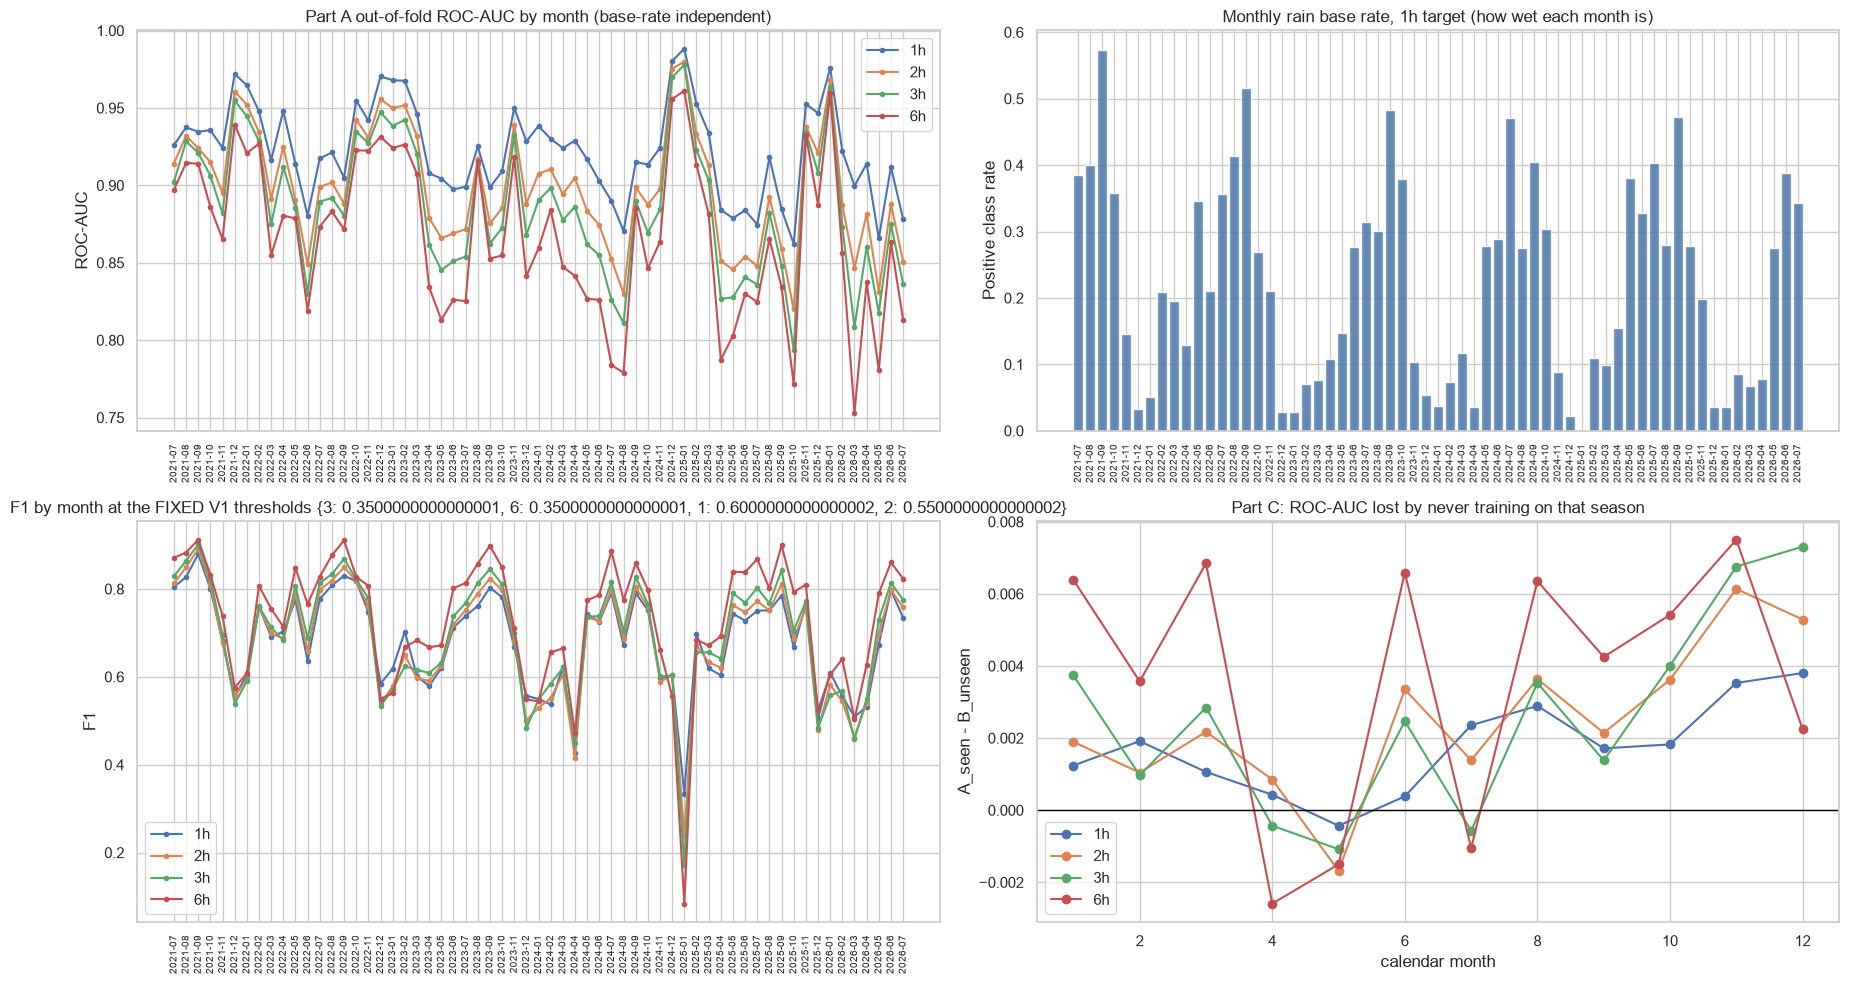

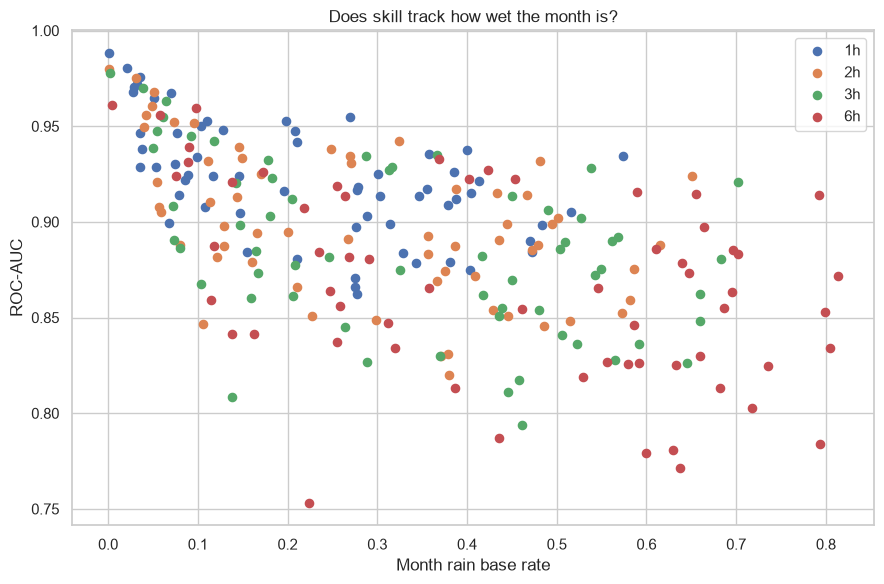

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

ax = axes[0][0]
for horizon in HORIZONS:
    sub = monthly[monthly["horizon_h"] == horizon]
    ax.plot(sub["month"], sub["roc_auc"], marker="o", ms=3, label=f"{horizon}h")
ax.set_title("Part A out-of-fold ROC-AUC by month (base-rate independent)")
ax.set_ylabel("ROC-AUC"); ax.legend(); ax.tick_params(axis="x", rotation=90, labelsize=7)

ax = axes[0][1]
sub1 = monthly[monthly["horizon_h"] == 1]
ax.bar(sub1["month"], sub1["rain_rate"], color="#4c78a8", alpha=0.85)
ax.set_title("Monthly rain base rate, 1h target (how wet each month is)")
ax.set_ylabel("Positive class rate"); ax.tick_params(axis="x", rotation=90, labelsize=7)

ax = axes[1][0]
for horizon in HORIZONS:
    sub = monthly[monthly["horizon_h"] == horizon]
    ax.plot(sub["month"], sub["f1"], marker="o", ms=3, label=f"{horizon}h")
ax.set_title(f"F1 by month at the FIXED V1 thresholds {V1_THRESHOLDS}")
ax.set_ylabel("F1"); ax.legend(); ax.tick_params(axis="x", rotation=90, labelsize=7)

ax = axes[1][1]
for horizon in HORIZONS:
    sub = contrast[contrast["horizon_h"] == horizon]
    ax.plot(sub["calendar_month"], sub["roc_auc_cost_of_unseen"], marker="o", label=f"{horizon}h")
ax.axhline(0, color="black", lw=1)
ax.set_title("Part C: ROC-AUC lost by never training on that season")
ax.set_xlabel("calendar month"); ax.set_ylabel("A_seen - B_unseen"); ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
for horizon in HORIZONS:
    sub = monthly[monthly["horizon_h"] == horizon]
    ax.scatter(sub["rain_rate"], sub["roc_auc"], s=35, label=f"{horizon}h")
ax.set_xlabel("Month rain base rate"); ax.set_ylabel("ROC-AUC")
ax.set_title("Does skill track how wet the month is?")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Save

In [14]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
monthly.to_csv(OUTPUT_DIR / "seasonal_cv_monthly_metrics.csv", index=False)
summary.to_csv(OUTPUT_DIR / "seasonal_cv_summary_vs_v1.csv", index=False)
fold_log.to_csv(OUTPUT_DIR / "seasonal_cv_fold_log.csv", index=False)
fold_table.to_csv(OUTPUT_DIR / "seasonal_cv_folds.csv", index=False)
contrast.to_csv(OUTPUT_DIR / "seasonal_cv_seen_vs_unseen.csv", index=False)
volume_control.to_csv(OUTPUT_DIR / "seasonal_cv_volume_control.csv", index=False)

metadata = {
    "purpose": ("year-blocked and season-blocked CV; separates 'harder season' from "
                "'season never trained on', which Thailand_Rain_Seasonal_CV could not"),
    "precompute_table": PRECOMPUTE_TABLE_NAME,
    "rows": int(x_all.shape[0]),
    "span": [str(forecast_time.min()), str(forecast_time.max())],
    "purge_hours": PURGE_HOURS,
    "part_a_year_folds": [str(y) for y in YEAR_FOLDS],
    "part_b_quarter_folds": {str(q): m for q, m in QUARTERS.items()},
    "volume_control_horizon": VOLUME_CONTROL_HORIZON,
    "volume_control_train_rows": int(target_train_rows),
    "model_plan": MODEL_PLAN,
    "v1_thresholds_used": V1_THRESHOLDS,
    "oof_coverage_a": float(np.isfinite(oof_a).all(axis=1).mean()),
    "oof_coverage_b": float(np.isfinite(oof_b).all(axis=1).mean()),
    "summary_vs_v1": summary.to_dict(orient="records"),
    "mean_cost_of_unseen_season_roc_by_horizon": contrast.groupby("horizon_h")[
        "roc_auc_cost_of_unseen"].mean().to_dict(),
    "caveat": ("Part A and Part B train on different row counts; section 6 measures that "
               "confound at 1h only. Labels come from Open-Meteo `precipitation`, which is "
               "ECMWF model output rather than an observation, so every number here is "
               "agreement with a forecast, not with measured rain."),
}
(OUTPUT_DIR / "seasonal_cv_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print(f"Saved seasonal CV results to {OUTPUT_DIR}")

Saved seasonal CV results to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\om_bkk_rain_any_seasonal_cv
